# 日経平均株価 週足 メディアン統計とモメンタム

In [1]:
import sys

path_up = ".."
if not path_up in sys.path:
    sys.path.append(path_up)

In [2]:
import datetime
import os

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import mplfinance as mpf
import numpy as np
import pandas as pd
import pingouin as pg
import seaborn as sns
import yfinance as yf
from scipy import stats

from funcs.technical import calc_robust_bollinger

In [3]:
code = "N225"
symbol = "^%s" % code
yticker = yf.Ticker(symbol)

In [4]:
### 最新のデータが取得されていることを確認 ###
yticker.history(period="7d", interval="1d")

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2026-08-27 00:00:00+09:00,66775.781250,66954.687500,65782.593750,66131.976562,133500000,0.0,0.0
2026-08-28 00:00:00+09:00,66104.492188,66842.820312,66012.203125,66405.562500,147000000,0.0,0.0
2026-08-31 00:00:00+09:00,65668.507812,66311.929688,64832.101562,66311.929688,185700000,0.0,0.0
2026-09-01 00:00:00+09:00,65885.468750,66525.703125,65576.609375,66215.343750,158600000,0.0,0.0
2026-09-02 00:00:00+09:00,65195.429688,65195.429688,64215.468750,64325.640625,172500000,0.0,0.0
2026-09-03 00:00:00+09:00,64724.808594,64724.808594,63772.800781,64214.480469,154100000,0.0,0.0
2026-09-04 00:00:00+09:00,64498.941406,65182.449219,64228.468750,65020.941406,155800000,0.0,0.0


In [5]:
# 週足で過去 5 年分のデータを取得
df0 = yticker.history(period="10y", interval="1wk")

# ローソク足のチャートには、そのうち過去 3 年分のみ使用する
dt_last = df0.index[len(df0) - 1]
tdelta_2y = datetime.timedelta(days=365 * 2)
df = df0[df0.index >= dt_last - tdelta_2y]

In [6]:
dt = df.tail(1).index[0]
year_str = f"{dt.year:04d}"
date_str = f"{dt.month:02d}{dt.day:02d}"
date_str

'0831'

## Moving Median

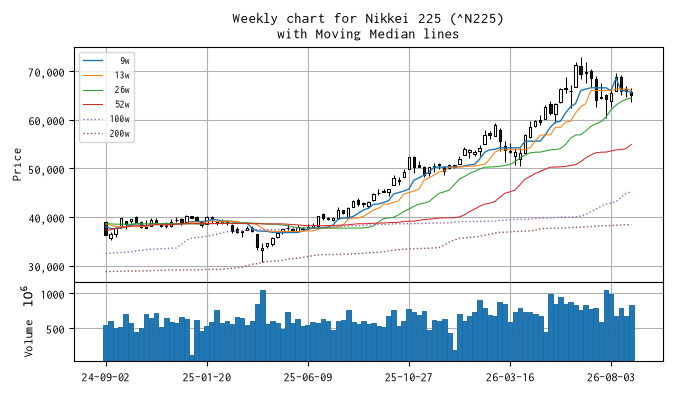

In [7]:
FONT_PATH = "../fonts/RictyDiminished-Regular.ttf"
fm.fontManager.addfont(FONT_PATH)

# FontPropertiesオブジェクト生成（名前の取得のため）
font_prop = fm.FontProperties(fname=FONT_PATH)
font_prop.get_name()

plt.rcParams["font.family"] = font_prop.get_name()
plt.rcParams["font.size"] = 9

fig = plt.figure(figsize=(6.8, 4))
ax = dict()
n = 2
gs = fig.add_gridspec(
    n, 1, wspace=0.0, hspace=0.0, height_ratios=[3 if i == 0 else 1 for i in range(n)]
)
for i, axis in enumerate(gs.subplots(sharex="col")):
    ax[i] = axis
    ax[i].grid()

mm09 = df0["Close"].rolling(9).median()
mm13 = df0["Close"].rolling(13).median()
mm26 = df0["Close"].rolling(26).median()
mm52 = df0["Close"].rolling(52).median()
mm100 = df0["Close"].rolling(100).median()
mm200 = df0["Close"].rolling(200).median()

apds = [
    mpf.make_addplot(mm09[df.index], width=1, label="  9w", ax=ax[0]),
    mpf.make_addplot(mm13[df.index], width=0.75, label=" 13w", ax=ax[0]),
    mpf.make_addplot(mm26[df.index], width=0.75, label=" 26w", ax=ax[0]),
    mpf.make_addplot(mm52[df.index], width=0.75, label=" 52w", ax=ax[0]),
    mpf.make_addplot(
        mm100[df.index],
        width=1,
        linestyle="dotted",
        label="100w",
        ax=ax[0],
    ),
    mpf.make_addplot(
        mm200[df.index],
        width=1,
        linestyle="dotted",
        label="200w",
        ax=ax[0],
    ),
]

mpf.plot(
    df,
    type="candle",
    style="default",
    volume=ax[1],
    datetime_format="%y-%m-%d",
    addplot=apds,
    xrotation=0,
    update_width_config=dict(candle_linewidth=0.75),
    ax=ax[0],
)

ax[0].yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))
ax[0].set_title(
    f"Weekly chart for {yticker.info["longName"]} ({symbol})\nwith Moving Median lines"
)
ax[0].legend(loc="upper left", fontsize=7)

plt.tight_layout()
plt.savefig(os.path.join(year_str, f"{date_str}_report_weekly_chart_median_{code}.png"))
plt.show()

In [8]:
df.tail(2)

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2026-08-24 00:00:00+09:00,65978.953125,66954.687500,64609.468750,66405.562500,669400000,0.0,0.0
2026-08-31 00:00:00+09:00,65668.507812,66525.703125,63772.800781,65020.941406,826700000,0.0,0.0


In [9]:
df.tail(2)["Close"]

Date
2026-08-24 00:00:00+09:00    66405.562500
2026-08-31 00:00:00+09:00    65020.941406
Name: Close, dtype: float64

In [10]:
df.tail(2)["Close"].diff()

Date
2026-08-24 00:00:00+09:00            NaN
2026-08-31 00:00:00+09:00   -1384.621094
Name: Close, dtype: float64

In [11]:
df["Close"].rolling(9).median().tail(10)

Date
2026-06-29 00:00:00+09:00    66329.500000
2026-07-06 00:00:00+09:00    66588.117188
2026-07-13 00:00:00+09:00    66588.117188
2026-07-20 00:00:00+09:00    66588.117188
2026-07-27 00:00:00+09:00    66588.117188
2026-08-03 00:00:00+09:00    66020.039062
2026-08-10 00:00:00+09:00    68557.726562
2026-08-17 00:00:00+09:00    66016.359375
2026-08-24 00:00:00+09:00    66016.359375
2026-08-31 00:00:00+09:00    65606.710938
Name: Close, dtype: float64

In [12]:
df["Close"].rolling(13).median().tail(10)

Date
2026-06-29 00:00:00+09:00    63339.070312
2026-07-06 00:00:00+09:00    66020.039062
2026-07-13 00:00:00+09:00    66020.039062
2026-07-20 00:00:00+09:00    66020.039062
2026-07-27 00:00:00+09:00    66020.039062
2026-08-03 00:00:00+09:00    66020.039062
2026-08-10 00:00:00+09:00    66329.500000
2026-08-17 00:00:00+09:00    66329.500000
2026-08-24 00:00:00+09:00    66405.562500
2026-08-31 00:00:00+09:00    66020.039062
Name: Close, dtype: float64

In [13]:
df["Close"].rolling(26).median().tail(5)

Date
2026-08-03 00:00:00+09:00    62061.468750
2026-08-10 00:00:00+09:00    63026.359375
2026-08-17 00:00:00+09:00    63740.095703
2026-08-24 00:00:00+09:00    64251.570312
2026-08-31 00:00:00+09:00    64486.583984
Name: Close, dtype: float64

In [14]:
df["Close"].rolling(52).median().tail(5)

Date
2026-08-03 00:00:00+09:00    53596.339844
2026-08-10 00:00:00+09:00    53833.240234
2026-08-17 00:00:00+09:00    53891.521484
2026-08-24 00:00:00+09:00    54094.925781
2026-08-31 00:00:00+09:00    54937.259766
Name: Close, dtype: float64

In [15]:
df0["Close"].rolling(100).median().tail(5)

Date
2026-08-03 00:00:00+09:00    42868.609375
2026-08-10 00:00:00+09:00    43198.529297
2026-08-17 00:00:00+09:00    44073.214844
2026-08-24 00:00:00+09:00    44906.964844
2026-08-31 00:00:00+09:00    45200.398438
Name: Close, dtype: float64

In [16]:
df0["Close"].rolling(200).median().tail(5)

Date
2026-08-03 00:00:00+09:00    38259.960938
2026-08-10 00:00:00+09:00    38324.060547
2026-08-17 00:00:00+09:00    38383.750000
2026-08-24 00:00:00+09:00    38427.345703
2026-08-31 00:00:00+09:00    38469.349609
Name: Close, dtype: float64

## Robust Bollinger bands

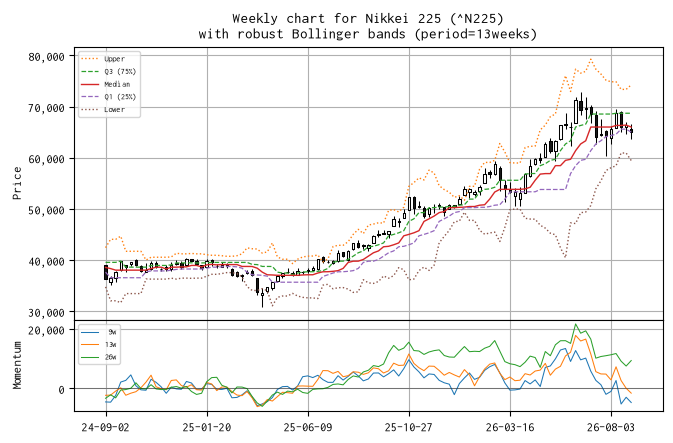

In [17]:
FONT_PATH = "../fonts/RictyDiminished-Regular.ttf"
fm.fontManager.addfont(FONT_PATH)

# FontPropertiesオブジェクト生成（名前の取得のため）
font_prop = fm.FontProperties(fname=FONT_PATH)
font_prop.get_name()

plt.rcParams["font.family"] = font_prop.get_name()
plt.rcParams["font.size"] = 9

# fig, ax = plt.subplots(figsize=(6, 3.5))
fig = plt.figure(figsize=(6.8, 4.5))
ax = dict()
n = 2
gs = fig.add_gridspec(
    n, 1, wspace=0.0, hspace=0.0, height_ratios=[3 if i == 0 else 1 for i in range(n)]
)
for i, axis in enumerate(gs.subplots(sharex="col")):
    ax[i] = axis
    ax[i].grid()

# Bollinger bands
period = 13
mv_median = df0["Close"].rolling(period).median()
mv_q1 = df0["Close"].rolling(period).quantile(0.25)
mv_q3 = df0["Close"].rolling(period).quantile(0.75)
mv_iqr = mv_q3 - mv_q1
mv_lower = mv_q1 - mv_iqr * 1.5
mv_upper = mv_q3 + mv_iqr * 1.5

mom09 = df0["Close"] - df0["Close"].shift(9, axis=0)
mom13 = df0["Close"] - df0["Close"].shift(13, axis=0)
mom26 = df0["Close"] - df0["Close"].shift(26, axis=0)

apds = [
    mpf.make_addplot(
        mv_upper[df.index],
        width=1,
        color="C1",
        linestyle="dotted",
        label="Upper",
        ax=ax[0],
    ),
    mpf.make_addplot(
        mv_q3[df.index],
        width=0.9,
        color="C2",
        linestyle="dashed",
        label="Q3 (75%)",
        ax=ax[0],
    ),
    mpf.make_addplot(
        mv_median[df.index],
        width=1,
        color="C3",
        linestyle="solid",
        label="Median",
        ax=ax[0],
    ),
    mpf.make_addplot(
        mv_q1[df.index],
        width=0.9,
        color="C4",
        linestyle="dashed",
        label="Q1 (25%)",
        ax=ax[0],
    ),
    mpf.make_addplot(
        mv_lower[df.index],
        width=1,
        color="C5",
        linestyle="dotted",
        label="Lower",
        ax=ax[0],
    ),
    mpf.make_addplot(
        mom09[df.index],
        width=0.75,
        linestyle="solid",
        label=" 9w",
        ax=ax[1],
    ),
    mpf.make_addplot(
        mom13[df.index],
        width=0.75,
        linestyle="solid",
        label="13w",
        ax=ax[1],
    ),
    mpf.make_addplot(
        mom26[df.index],
        width=0.75,
        linestyle="solid",
        label="26w",
        ax=ax[1],
    ),
]

mpf.plot(
    df,
    type="candle",
    style="default",
    addplot=apds,
    datetime_format="%y-%m-%d",
    xrotation=0,
    update_width_config=dict(candle_linewidth=0.75),
    ax=ax[0],
)

# ax.grid()
ax[0].yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))
ax[0].legend(loc="best", fontsize=6)

ax[1].axhline(y=0, color="black", alpha=0.5, linewidth=0.5)
ax[1].yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))
ax[1].set_ylabel("Momentum")
ax[1].legend(loc="best", fontsize=6)

try:
    ax[0].set_title(
        f"Weekly chart for {yticker.info['longName']} ({symbol})\nwith robust Bollinger bands (period={period}weeks)"
    )
except KeyError:
    ax[0].set_title(
        f"Weekly chart for {symbol}\nwith robust Bollinger bands (period={period}weeks)"
    )

plt.tight_layout()
plt.savefig(
    os.path.join(
        year_str, f"{date_str}_report_weekly_chart_bollinger_robust_{code}.png"
    )
)
plt.show()

## ヒストグラムと Q-Q プロット

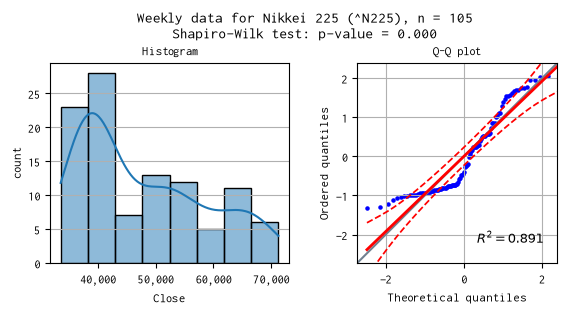

In [18]:
plt.rcParams["font.size"] = 9
fig, axes = plt.subplots(1, 2, figsize=(6.8, 3))

sns.histplot(df["Close"], kde=True, ax=axes[0])

# ヒストグラム
axes[0].set_xlabel("Close")
axes[0].set_ylabel("count")
axes[0].xaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))
axes[0].grid(axis="y")
axes[0].set_title("Histogram", fontsize=9)

# Q-Q プロット
pg.qqplot(df["Close"], s=5, ax=axes[1])
axes[1].set_title("Q-Q plot", fontsize=9)
axes[1].grid()

shapiro_test = stats.shapiro(df["Close"])
title_str = (
    f"Weekly data for {yticker.info["longName"]} ({symbol}), n = {len(df)}\n"
    f"Shapiro-Wilk test: p-value = {shapiro_test.pvalue:.3f}"
)
plt.suptitle(
    title_str,
    fontsize=11,
)
plt.subplots_adjust(top=0.80, bottom=0.135, wspace=0.2)
plt.savefig(
    os.path.join(year_str, f"{date_str}_report_weekly_histogram_qqplot_{code}.png")
)
plt.show()